# **Import things**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from math import floor
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)

# **Data Exploration**

## **Load the data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 6550 Rows and 10 columns with 50 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6550 entries, 0 to 6549
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   study_hours_per_day  6417 non-null   float64
 1   attendance_percent   6421 non-null   str    
 2   previous_score       6419 non-null   float64
 3   sleep_hours          6419 non-null   float64
 4   assignments_done     6418 non-null   float64
 5   has_tuition          6420 non-null   float64
 6   parent_education     6419 non-null   float64
 7   motivation_score     6419 non-null   float64
 8   internet_hours       6419 non-null   float64
 9   passed               6550 non-null   int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 537.9 KB


In [5]:
df.sample(10)

,study_hours_per_day,attendance_percent,previous_score,sleep_hours,assignments_done,has_tuition,parent_education,motivation_score,internet_hours,passed
2184,4.2,89.2,36.0,6.6,2.0,1.0,2.0,3.7,1.0,1
5632,6.4,47.4,90.0,9.6,15.0,0.0,2.0,5.7,2.0,1
4936,4.7,31.3,72.5,7.6,1.0,1.0,2.0,8.5,2.7,1
3737,8.1,67.9,60.4,6.3,3.0,1.0,0.0,2.7,5.9,1
267,2.1,56.6,43.5,5.5,3.0,1.0,2.0,8.8,1.9,0
1575,NaN,84.7,62.3,5.4,2.0,0.0,0.0,6.5,2.6,1
5067,5.6,83.5,42.0,8.7,18.0,0.0,2.0,3.6,2.7,1
710,4.9,59.4,89.7,5.2,1.0,1.0,2.0,6.5,6.9,1
3790,9.6,39.8,54.7,8.7,3.0,0.0,0.0,9.1,0.3,1
2639,4.7,45.0,86.0,8.1,17.0,0.0,2.0,3.6,5.1,1


In [6]:
df.describe()

,study_hours_per_day,previous_score,sleep_hours,assignments_done,has_tuition,parent_education,motivation_score,internet_hours,passed
count,6417.000000,6419.000000,6419.000000,6418.000000,6420.000000,6419.000000,6419.000000,6419.000000,6550.000000
mean,4.996525,57.737046,6.978003,9.564974,0.452336,1.004206,5.540832,3.951721,0.504427
std,2.873595,21.596727,1.735632,5.690931,0.497762,0.821464,2.598777,2.296026,0.500019
min,-5.000000,-10.000000,-3.000000,0.000000,0.000000,0.000000,1.000000,-2.000000,0.000000
25%,2.500000,38.900000,5.500000,5.000000,0.000000,0.000000,3.300000,2.000000,0.000000
50%,5.000000,57.700000,7.000000,10.000000,0.000000,1.000000,5.500000,3.900000,1.000000
75%,7.500000,76.600000,8.500000,14.000000,1.000000,2.000000,7.800000,5.900000,1.000000
max,10.000000,95.000000,10.000000,19.000000,1.000000,2.000000,15.000000,8.000000,1.000000


In [7]:
df.isna().sum()

study_hours_per_day    133
attendance_percent     129
previous_score         131
sleep_hours            131
assignments_done       132
has_tuition            130
parent_education       131
motivation_score       131
internet_hours         131
passed                   0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy Created')

Copy Created


## **DataType**

In [10]:
df_copy['attendance_percent'] = df_copy['attendance_percent'].replace('_err','',regex=True).astype('float')

## **impossible Values**

In [13]:
Columns = df_copy.columns.tolist()

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

In [15]:
Columns = df_copy.columns.tolist()
Columns.remove('passed')
Columns.remove('has_tuition')
Columns.remove('parent_education')

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [17]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 50
After: 0


In [18]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('passed')
Round.remove('assignments_done')
Round.remove('has_tuition')
Round.remove('parent_education')
for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['assignments_done','has_tuition','parent_education']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
study_hours_per_day    131
attendance_percent     131
previous_score         131
sleep_hours            131
assignments_done       130
has_tuition            130
parent_education       130
motivation_score       131
internet_hours         131
passed                   0
dtype: int64
NaN values in the Dataset After Cleaning is: 
study_hours_per_day    0
attendance_percent     0
previous_score         0
sleep_hours            0
assignments_done       0
has_tuition            0
parent_education       0
motivation_score       0
internet_hours         0
passed                 0
dtype: int64


# **Data Preperation**

In [19]:
features = df_copy.columns.tolist()
features.remove('passed')
X = df_copy[features]
y = df_copy['passed']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (6500, 9)
y Shape: (6500,)


In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (5200, 9)
X_test Shape:  (1300, 9)
y_train Shape: (5200,)
y_test Shape:  (1300,)


# **Model**

## **C tunning**

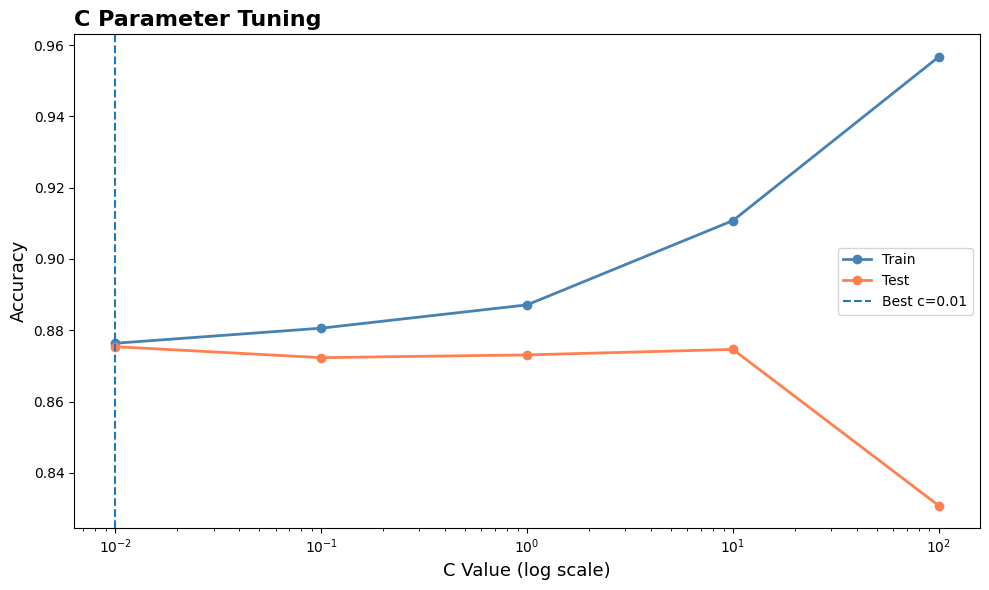

In [21]:
C_values = [0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores  = []

for c in C_values:
    pipe = Pipeline([
        ('scaler' , StandardScaler()),
        ('svm', SVC(C=c,kernel='rbf',random_state=42,gamma='scale'))
    ])
    pipe.fit(X_train,y_train)
    train_scores.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  pipe.predict(X_test)))
    
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_scores, marker='o', label='Train',
         color='steelblue', linewidth=2)
plt.plot(C_values, test_scores,  marker='o', label='Test',
         color='coral', linewidth=2)
plt.xscale('log')
plt.xlabel('C Value (log scale)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('C Parameter Tuning', fontweight='bold',
          fontsize=16, loc='left')
best_index = np.argmax(test_scores)
best_c = C_values[best_index]
best_score = test_scores[best_index]
plt.axvline(best_c, linestyle='--', label=f'Best c={best_c}')
plt.legend()
plt.tight_layout()
plt.show()
    

## **Train**

In [22]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('svm',SVC(C=0.01,probability=True,random_state=42,kernel='rbf',gamma='scale'))
])
pipeline.fit(X_train,y_train)
print("Model trained ✅")

Model trained ✅


## **Evaluation**

In [23]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87       641
         1.0       0.88      0.88      0.88       659

    accuracy                           0.88      1300
   macro avg       0.88      0.88      0.88      1300
weighted avg       0.88      0.88      0.88      1300

Accuracy: 0.8754


## **OverFitting**

In [24]:
train_acc = accuracy_score(y_train, pipeline.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.8763
Testing Accuracy:  0.8754
Gap:               0.0010


## **Charts**

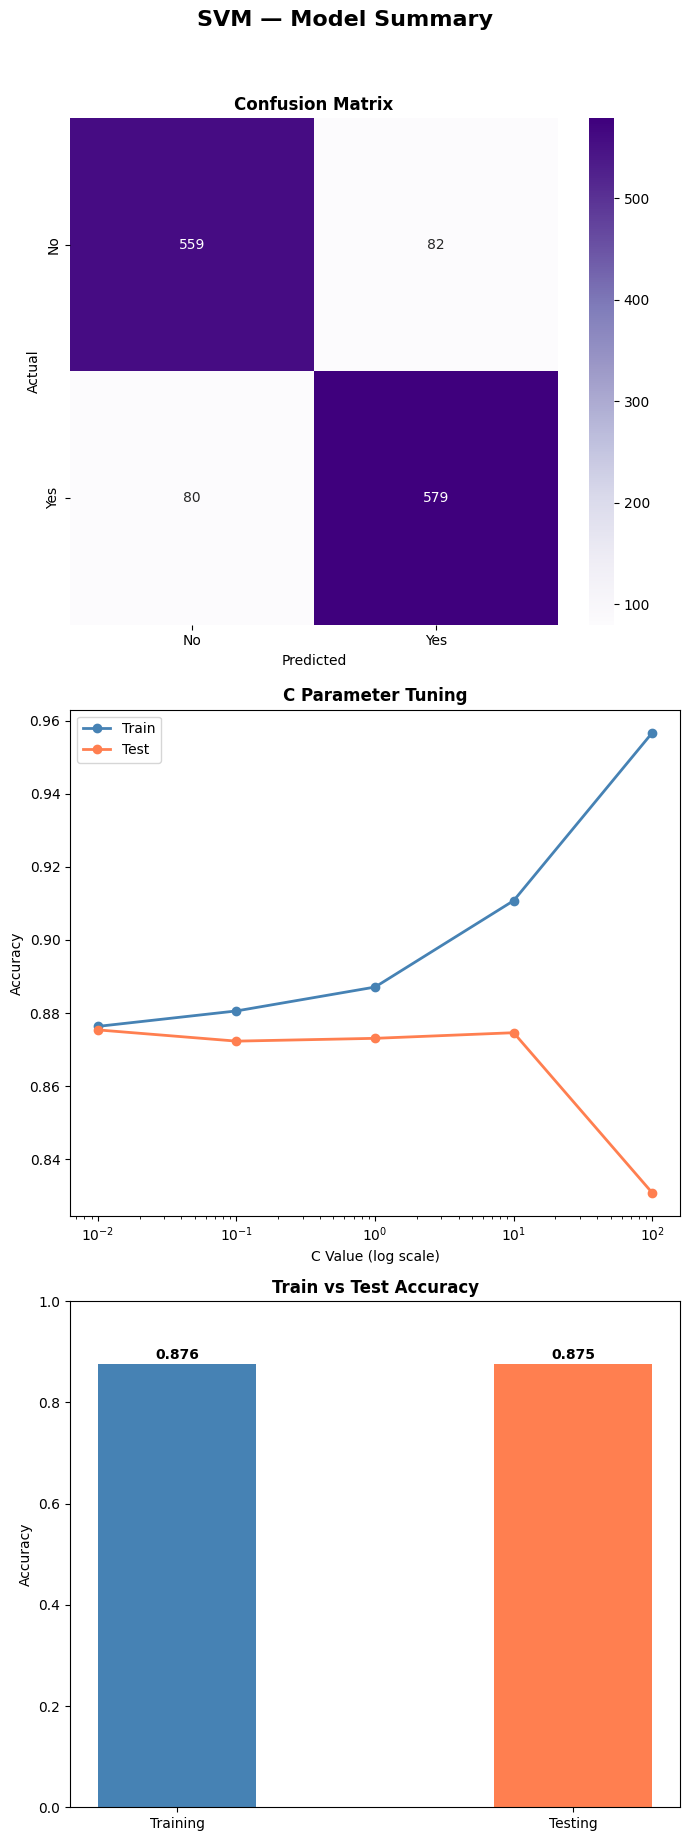

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — C Parameter Tuning
axes[1].plot(C_values, train_scores, marker='o',
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(C_values, test_scores,  marker='o',
             label='Test',  color='coral',     linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title('C Parameter Tuning', fontweight='bold')
axes[1].set_xlabel('C Value (log scale)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3 — Train vs Test Accuracy
labels = ['Training', 'Testing']
scores = [train_acc, test_acc]
colors = ['steelblue', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('SVM — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()